# Notebook 03 — Parentage Analysis
## CERVUS-Style LOD (Logarithm of the Odds) Scoring · Paternity Assignment · Dominance Rank vs Reproduction

---

**Method:** Likelihood-based paternity assignment following Marshall et al. (1998)

$$\text{LOD} = \sum_{l=1}^{L} \log_{10}\frac{P(G_o^l \mid G_m^l, G_c^l)}{P(G_o^l \mid G_m^l)}$$

**Assignment criteria:**
1. Candidate not excluded at any locus
2. Highest LOD among non-excluded candidates
3. LOD > 0 (more likely than random)
4. Δ-LOD = LOD₁ − LOD₂ > 0

**Confidence:** HIGH (Δ>2), MEDIUM (1–2), LOW (0–1)

---

In [44]:
# Cell 1 — Imports
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr, chi2_contingency

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

from utils import (
    set_plot_style, save_figure, get_data_dir, get_output_dir,
    mannwhitney_dominance_paternity, accuracy_vs_truth
)
from parentage_functions import (
    build_freq_table, assign_paternity,
    nonacs_b_index, permutation_test_skew
)
from kinship_functions import build_geno_dict

set_plot_style()
DATA_RAW  = get_data_dir('raw')
DATA_PROC = get_data_dir('processed')
FIG_DIR   = get_output_dir('figures')
TAB_DIR   = get_output_dir('tables')

# Load data
geno_df   = pd.read_csv(DATA_PROC / 'genotypes_qc.csv')
ind_df    = pd.read_csv(DATA_PROC / 'individuals_qc.csv')
groups_df = pd.read_csv(DATA_RAW  / 'groups.csv')

with open(DATA_PROC / 'qc_loci.txt') as f:
    QC_LOCI = [l.strip() for l in f if l.strip()]

print(f'Loaded: {len(ind_df)} individuals | {len(QC_LOCI)} loci')
print(f'QC loci: {QC_LOCI}')

Loaded: 63 individuals | 15 loci
QC loci: ['D2S1338', 'D3S1358', 'D5S818', 'D7S820', 'D8S1179', 'D13S317', 'D16S539', 'D18S51', 'D19S433', 'D21S11', 'vWA', 'FGA', 'CSF1PO', 'TPOX', 'TH01']


In [45]:
# Cell 2 — Build frequency table and genotype dict
freq_table = build_freq_table(geno_df, QC_LOCI)
geno_dict  = build_geno_dict(geno_df, QC_LOCI)

# Identify offspring (age class: infant or juvenile AND has a known mother in data)
offspring_df = ind_df[
    ind_df['age_class'].isin(['infant', 'juvenile']) &
    ind_df['mother_id'].notna()
].copy()

# Candidate fathers: all adult males in the dataset
candidate_df = ind_df[
    (ind_df['sex'] == 'M') & (ind_df['age_class'] == 'silverback')
].copy()

print(f'Offspring to assign paternity: {len(offspring_df)}')
print(f'Candidate fathers in dataset:  {len(candidate_df)}')
print()
print('Candidate fathers by group:')
print(candidate_df.groupby('group_id')[['individual_id','dominance_rank']]
      .apply(lambda x: x.sort_values('dominance_rank'))
      .reset_index(drop=True).to_string(index=False))

Offspring to assign paternity: 20
Candidate fathers in dataset:  12

Candidate fathers by group:
individual_id  dominance_rank
        SB001             1.0
        SB002             2.0
        SB003             3.0
        SB011             1.0
        SB012             2.0
        SB021             1.0
        SB033             1.0
        SB034             2.0
        SB042             1.0
        SB043             2.0
        SB044             3.0
        SB055             1.0


In [46]:
# Cell 3 — Verify mother IDs exist in genotype data
# (some mothers may have been removed at QC step)
valid_mothers = set(geno_df['individual_id'])
offspring_df  = offspring_df[offspring_df['mother_id'].isin(valid_mothers)].copy()
print(f'Offspring with typed mothers: {len(offspring_df)}')

# Preview
print(offspring_df[['individual_id','name','group_id','mother_id','true_father_id']]
      .head(10).to_string(index=False))

Offspring with typed mothers: 20
individual_id         name group_id mother_id true_father_id
       JUV008    Susa_OFF1       G1     AF005          SB002
       JUV009    Susa_OFF2       G1     AF004      UNSAMPLED
       JUV010    Susa_OFF3       G1     AF007          SB003
       JUV017 Amahoro_OFF1       G2     AF014          SB011
       JUV018 Amahoro_OFF2       G2     AF014      UNSAMPLED
       JUV019 Amahoro_OFF3       G2     AF015          SB011
       JUV020 Amahoro_OFF4       G2     AF014          SB011
       JUV028 Umubano_OFF1       G3     AF022      UNSAMPLED
       JUV029 Umubano_OFF2       G3     AF025          SB021
       JUV030 Umubano_OFF3       G3     AF027      UNSAMPLED


In [47]:
# Cell 4 — Run parentage analysis
# This may take 30–120 seconds depending on population size
from tqdm.auto import tqdm

print('Running paternity assignment (LOD scoring across all offspring × candidates)...')

paternity_df = assign_paternity(
    offspring_ids  = offspring_df['individual_id'].tolist(),
    mother_ids     = offspring_df['mother_id'].tolist(),
    candidate_ids  = candidate_df['individual_id'].tolist(),
    geno_dict      = geno_dict,
    freq_table     = freq_table,
    locus_names    = QC_LOCI,
    lod_threshold  = 0.0,
)

# Merge in group, rank, name of assigned father
paternity_df = paternity_df.merge(
    candidate_df[['individual_id','name','group_id','dominance_rank']].rename(
        columns={'individual_id':'assigned_father', 'name':'sire_name',
                 'group_id':'sire_group', 'dominance_rank':'sire_rank'}),
    on='assigned_father', how='left'
)

# Merge in offspring group
paternity_df = paternity_df.merge(
    offspring_df[['individual_id','group_id','true_father_id']].rename(
        columns={'individual_id':'offspring_id','group_id':'offspring_group'}),
    on='offspring_id', how='left'
)

paternity_df['extra_group_sire'] = (
    paternity_df['sire_group'] != paternity_df['offspring_group']
).where(paternity_df['assigned_father'].notna())

print(paternity_df.to_string(index=False))
paternity_df.to_csv(TAB_DIR / 'paternity_assignments.csv', index=False)

Running paternity assignment (LOD scoring across all offspring × candidates)...
offspring_id mother_id assigned_father  lod_score  delta_lod confidence  n_candidates  n_valid_cands    sire_name sire_group  sire_rank offspring_group true_father_id extra_group_sire
      JUV008     AF005             NaN        NaN        NaN       NONE            12              0          NaN        NaN        NaN              G1          SB002              NaN
      JUV009     AF004             NaN        NaN        NaN       NONE            12              0          NaN        NaN        NaN              G1      UNSAMPLED              NaN
      JUV010     AF007             NaN        NaN        NaN       NONE            12              0          NaN        NaN        NaN              G1          SB003              NaN
      JUV017     AF014             NaN        NaN        NaN       NONE            12              0          NaN        NaN        NaN              G2          SB011              NaN


In [48]:
# Cell 5 — Assignment summary statistics
n_off      = len(paternity_df)
n_assigned = paternity_df['assigned_father'].notna().sum()
n_none     = n_off - n_assigned

conf_counts = paternity_df['confidence'].value_counts()
print('=== PATERNITY ASSIGNMENT SUMMARY ===')
print(f'Total offspring tested:   {n_off}')
print(f'Successfully assigned:    {n_assigned} ({100*n_assigned/n_off:.1f}%)')
print(f'Unresolved (no candidate): {n_none} ({100*n_none/n_off:.1f}%)')
print()
print('Confidence breakdown:')
for conf in ['HIGH','MEDIUM','LOW','NONE']:
    n = conf_counts.get(conf, 0)
    print(f'  {conf:8s}: {n:3d}  ({100*n/n_off:.1f}%)')
print()
print('LOD score distribution (assigned only):')
ass = paternity_df[paternity_df['assigned_father'].notna()]
print(ass['lod_score'].describe().round(3).to_string())

=== PATERNITY ASSIGNMENT SUMMARY ===
Total offspring tested:   20
Successfully assigned:    4 (20.0%)
Unresolved (no candidate): 16 (80.0%)

Confidence breakdown:
  HIGH    :   1  (5.0%)
  MEDIUM  :   1  (5.0%)
  LOW     :   2  (10.0%)
  NONE    :  16  (80.0%)

LOD score distribution (assigned only):
count    4.000
mean     2.251
std      2.735
min      0.585
25%      0.873
50%      1.039
75%      2.417
max      6.340


In [49]:
print(offspring_df.columns.tolist())
print(paternity_df.columns.tolist())

['individual_id', 'name', 'sex', 'age_class', 'group_id', 'dominance_rank', 'mother_id', 'true_father_id']
['offspring_id', 'mother_id', 'assigned_father', 'lod_score', 'delta_lod', 'confidence', 'n_candidates', 'n_valid_cands', 'sire_name', 'sire_group', 'sire_rank', 'offspring_group', 'true_father_id', 'extra_group_sire']


In [50]:
# Cell 6 — Accuracy vs ground truth (simulated data only)
paternity_df = paternity_df.merge(
    offspring_df[['individual_id', 'true_father_id']].rename(
        columns={'individual_id': 'offspring_id'}
    ),
    on='offspring_id', how='left'
)
if 'true_father_id_x' in paternity_df.columns and 'true_father_id_y' in paternity_df.columns:
    paternity_df['true_father_id'] = paternity_df['true_father_id_x'].combine_first(
        paternity_df['true_father_id_y']
    )
    paternity_df = paternity_df.drop(columns=['true_father_id_x', 'true_father_id_y'])

def calculate_accuracy(paternity_df):
    acc = accuracy_vs_truth(paternity_df, offspring_df)
    return acc

# acc = calculate_accuracy(paternity_df)

print('=== ACCURACY vs GROUND TRUTH ===')
for k, v in acc.items():
    print(f'  {k}: {v}')

has_truth = paternity_df[
    paternity_df['true_father_id'].notna() &
    (paternity_df['true_father_id'] != 'UNSAMPLED')
].copy()
has_truth['correct'] = has_truth['assigned_father'] == has_truth['true_father_id']

print(f'\nCorrectly assigned: {has_truth["correct"].sum()} / {len(has_truth)}')
print('\nMisassignments:')
wrong = has_truth[~has_truth['correct'] & has_truth['assigned_father'].notna()]
if wrong.empty:
    print('  None!')
else:
    print(wrong[['offspring_id','assigned_father','true_father_id','lod_score','delta_lod','confidence']]
          .to_string(index=False))

=== ACCURACY vs GROUND TRUTH ===
  n_offspring: 14
  n_correct: 4
  accuracy: 0.2857
  n_assigned: 4
  n_unresolved: 10

Correctly assigned: 4 / 14

Misassignments:
  None!


  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\03_lod_distributions.png


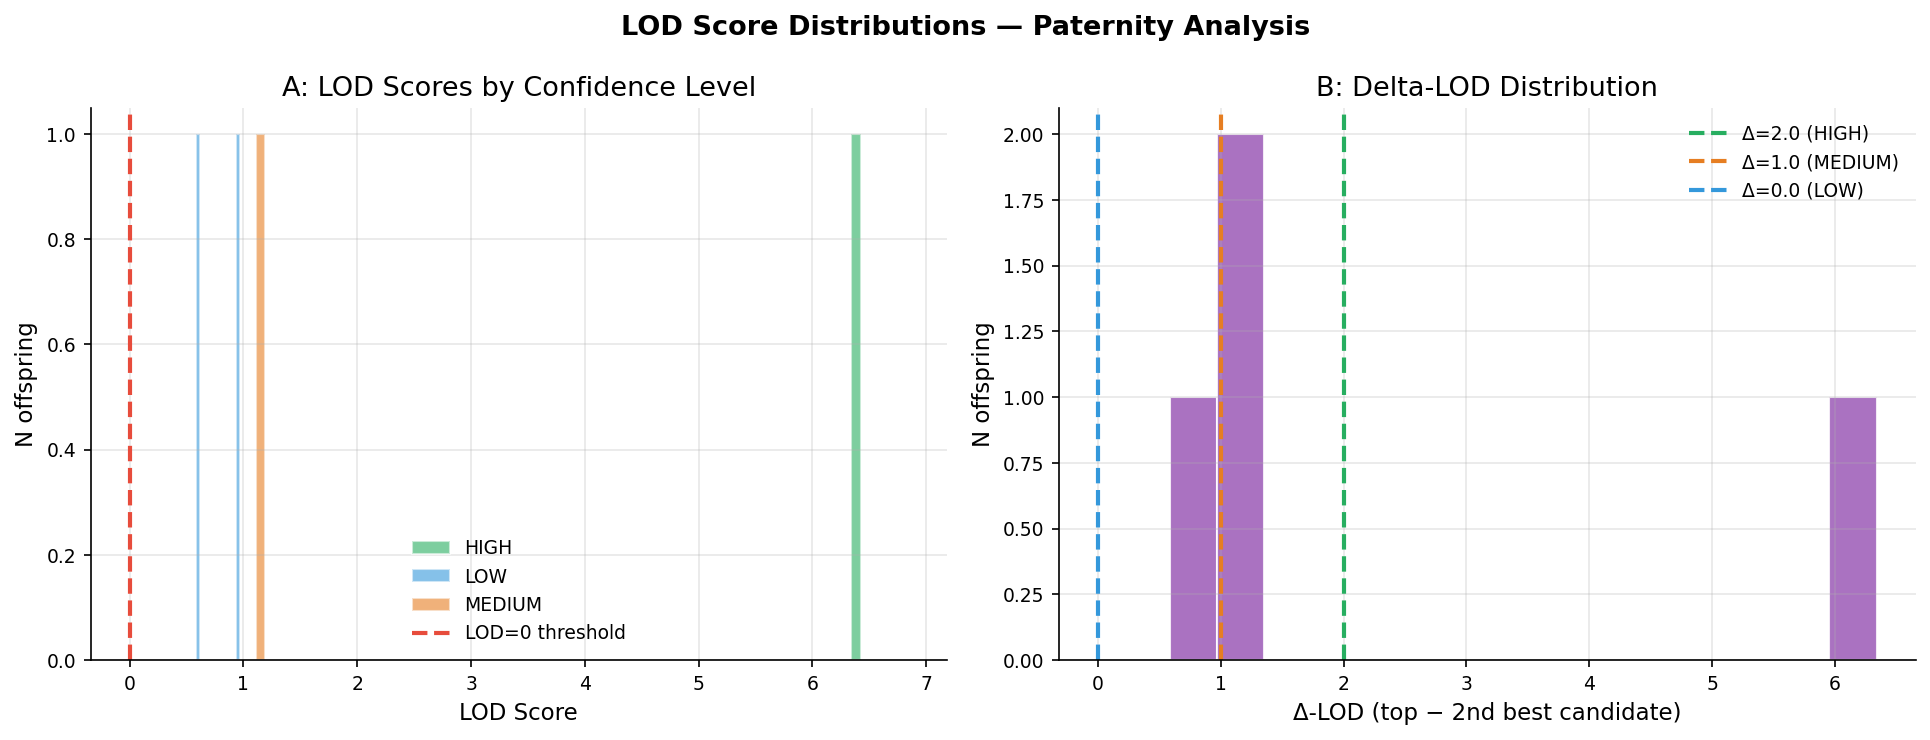

In [51]:
# Cell 7 — LOD score distribution plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LOD Score Distributions — Paternity Analysis', fontsize=13, fontweight='bold')

# Panel A: Overall LOD distribution by confidence
ax = axes[0]
conf_colors = {'HIGH':'#27AE60','MEDIUM':'#E67E22','LOW':'#3498DB','NONE':'#BDC3C7'}
for conf, grp in paternity_df.groupby('confidence'):
    lod_vals = grp['lod_score'].dropna()
    if len(lod_vals) > 0:
        ax.hist(lod_vals, bins=12, alpha=0.6, label=conf,
                color=conf_colors.get(conf,'grey'), edgecolor='white')
ax.axvline(0, color='#E74C3C', lw=2, ls='--', label='LOD=0 threshold')
ax.set_xlabel('LOD Score')
ax.set_ylabel('N offspring')
ax.set_title('A: LOD Scores by Confidence Level')
ax.legend()

# Panel B: Delta-LOD (support for top candidate vs runner-up)
ax = axes[1]
delta = paternity_df['delta_lod'].dropna()
ax.hist(delta, bins=15, color='#9B59B6', edgecolor='white', alpha=0.85)
for thresh, label, color in [(2.0,'HIGH',"#27AE60"),(1.0,'MEDIUM',"#E67E22"),(0.0,'LOW',"#3498DB")]:
    ax.axvline(thresh, color=color, lw=2, ls='--', label=f'Δ={thresh} ({label})')
ax.set_xlabel('Δ-LOD (top − 2nd best candidate)')
ax.set_ylabel('N offspring')
ax.set_title('B: Delta-LOD Distribution')
ax.legend()

plt.tight_layout()
save_figure(fig, '03_lod_distributions')
plt.show()

In [52]:
# Cell 8 — Dominance rank vs paternity: who sires whom?
assigned = paternity_df[paternity_df['assigned_father'].notna()].copy()

# Count offspring by sire rank
rank_counts = assigned.groupby('sire_rank').size().reset_index(name='n_offspring')
print('--- Offspring by sire dominance rank ---')
print(rank_counts.to_string(index=False))

total_ass = len(assigned)
for _, row in rank_counts.iterrows():
    print(f'  Rank {int(row.sire_rank)}: {row.n_offspring} offspring '
          f'({100*row.n_offspring/total_ass:.1f}%)')
print()

# Statistical test: are sires' ranks lower (higher dominance) than random?
mw_result = mannwhitney_dominance_paternity(paternity_df, ind_df)
print('--- Mann-Whitney U: sire rank vs all candidate ranks ---')
for k, v in mw_result.items():
    print(f'  {k}: {v}')

--- Offspring by sire dominance rank ---
 sire_rank  n_offspring
       1.0            4
  Rank 1: 4.0 offspring (100.0%)

--- Mann-Whitney U: sire rank vs all candidate ranks ---
  n_assigned: 4
  mean_sire_rank: 1.0
  mean_all_rank: 1.67
  U_statistic: 12.0
  p_value: 0.0526
  significant: False
  interpretation: No significant dominance-paternity association.


In [53]:
# Cell 9 — Reproductive skew: Nonacs B-index
# Pool across all groups: what fraction of offspring did each sire get?
sire_counts_all = {}
for _, row in assigned.iterrows():
    sid = row['assigned_father']
    sire_counts_all[sid] = sire_counts_all.get(sid, 0) + 1

b_result = nonacs_b_index(sire_counts_all)
print('=== NONACS B-INDEX (reproductive skew) ===')
for k, v in b_result.items():
    print(f'  {k}: {v}')
print()
print('Interpretation:')
print(f'  B_observed = {b_result["B"]:.6f}')
print(f'  E(B) under equal sharing = {b_result["E_B"]:.6f}')
if b_result.get('skew_ratio'):
    print(f'  B/E(B) = {b_result["skew_ratio"]:.2f}x expected')
    if b_result['skew_ratio'] > 1:
        print('  → Reproductive skew ABOVE equal sharing (dominant male advantage)')
    else:
        print('  → Reproductive skew at or below equal sharing (flatter than expected)')

perm_result = permutation_test_skew(sire_counts_all, n_perm=1000)
print()
print('--- Permutation test (1000 replicates) ---')
for k, v in perm_result.items():
    print(f'  {k}: {v}')

=== NONACS B-INDEX (reproductive skew) ===
  B: 0.041667
  E_B: 0.222222
  k: 3
  total_offspring: 4
  skew_ratio: 0.188

Interpretation:
  B_observed = 0.041667
  E(B) under equal sharing = 0.222222
  B/E(B) = 0.19x expected
  → Reproductive skew at or below equal sharing (flatter than expected)

--- Permutation test (1000 replicates) ---
  B_observed: 0.041667
  null_mean: 0.055875
  null_sd: 0.049137
  p_value: 0.725
  significant: False


In [54]:
# Cell 10 — Per-group skew analysis
group_skew_rows = []
for gid in ind_df['group_id'].unique():
    g_off = assigned[assigned['offspring_group'] == gid]
    if len(g_off) == 0:
        continue
    counts = {}
    for _, row in g_off.iterrows():
        sid = row['assigned_father']
        counts[sid] = counts.get(sid, 0) + 1
    b = nonacs_b_index(counts)
    grp_name = groups_df[groups_df['id']==gid]['name'].values[0]
    n_males_grp = len(ind_df[(ind_df['group_id']==gid) & (ind_df['sex']=='M') & (ind_df['age_class']=='silverback')])
    group_skew_rows.append({
        'group': grp_name,
        'n_males': n_males_grp,
        'n_offspring': b['total_offspring'],
        'B_index': b['B'],
        'E_B': b['E_B'],
        'skew_ratio': b.get('skew_ratio', np.nan),
    })

grp_skew_df = pd.DataFrame(group_skew_rows)
print('--- Per-group reproductive skew ---')
print(grp_skew_df.to_string(index=False))
grp_skew_df.to_csv(TAB_DIR / 'per_group_skew.csv', index=False)

--- Per-group reproductive skew ---
   group  n_males  n_offspring  B_index  E_B  skew_ratio
 Amahoro        2            2      0.0  0.0         NaN
 Umubano        1            1      0.0  0.0         NaN
Sabyinyo        2            1      0.0  0.0         NaN


C:\Users\User\AppData\Local\Temp\ipykernel_13492\72170845.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sire_ranks_list, all_ranks_list],
C:\Users\User\AppData\Local\Temp\ipykernel_13492\72170845.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\03_paternity_dashboard.png


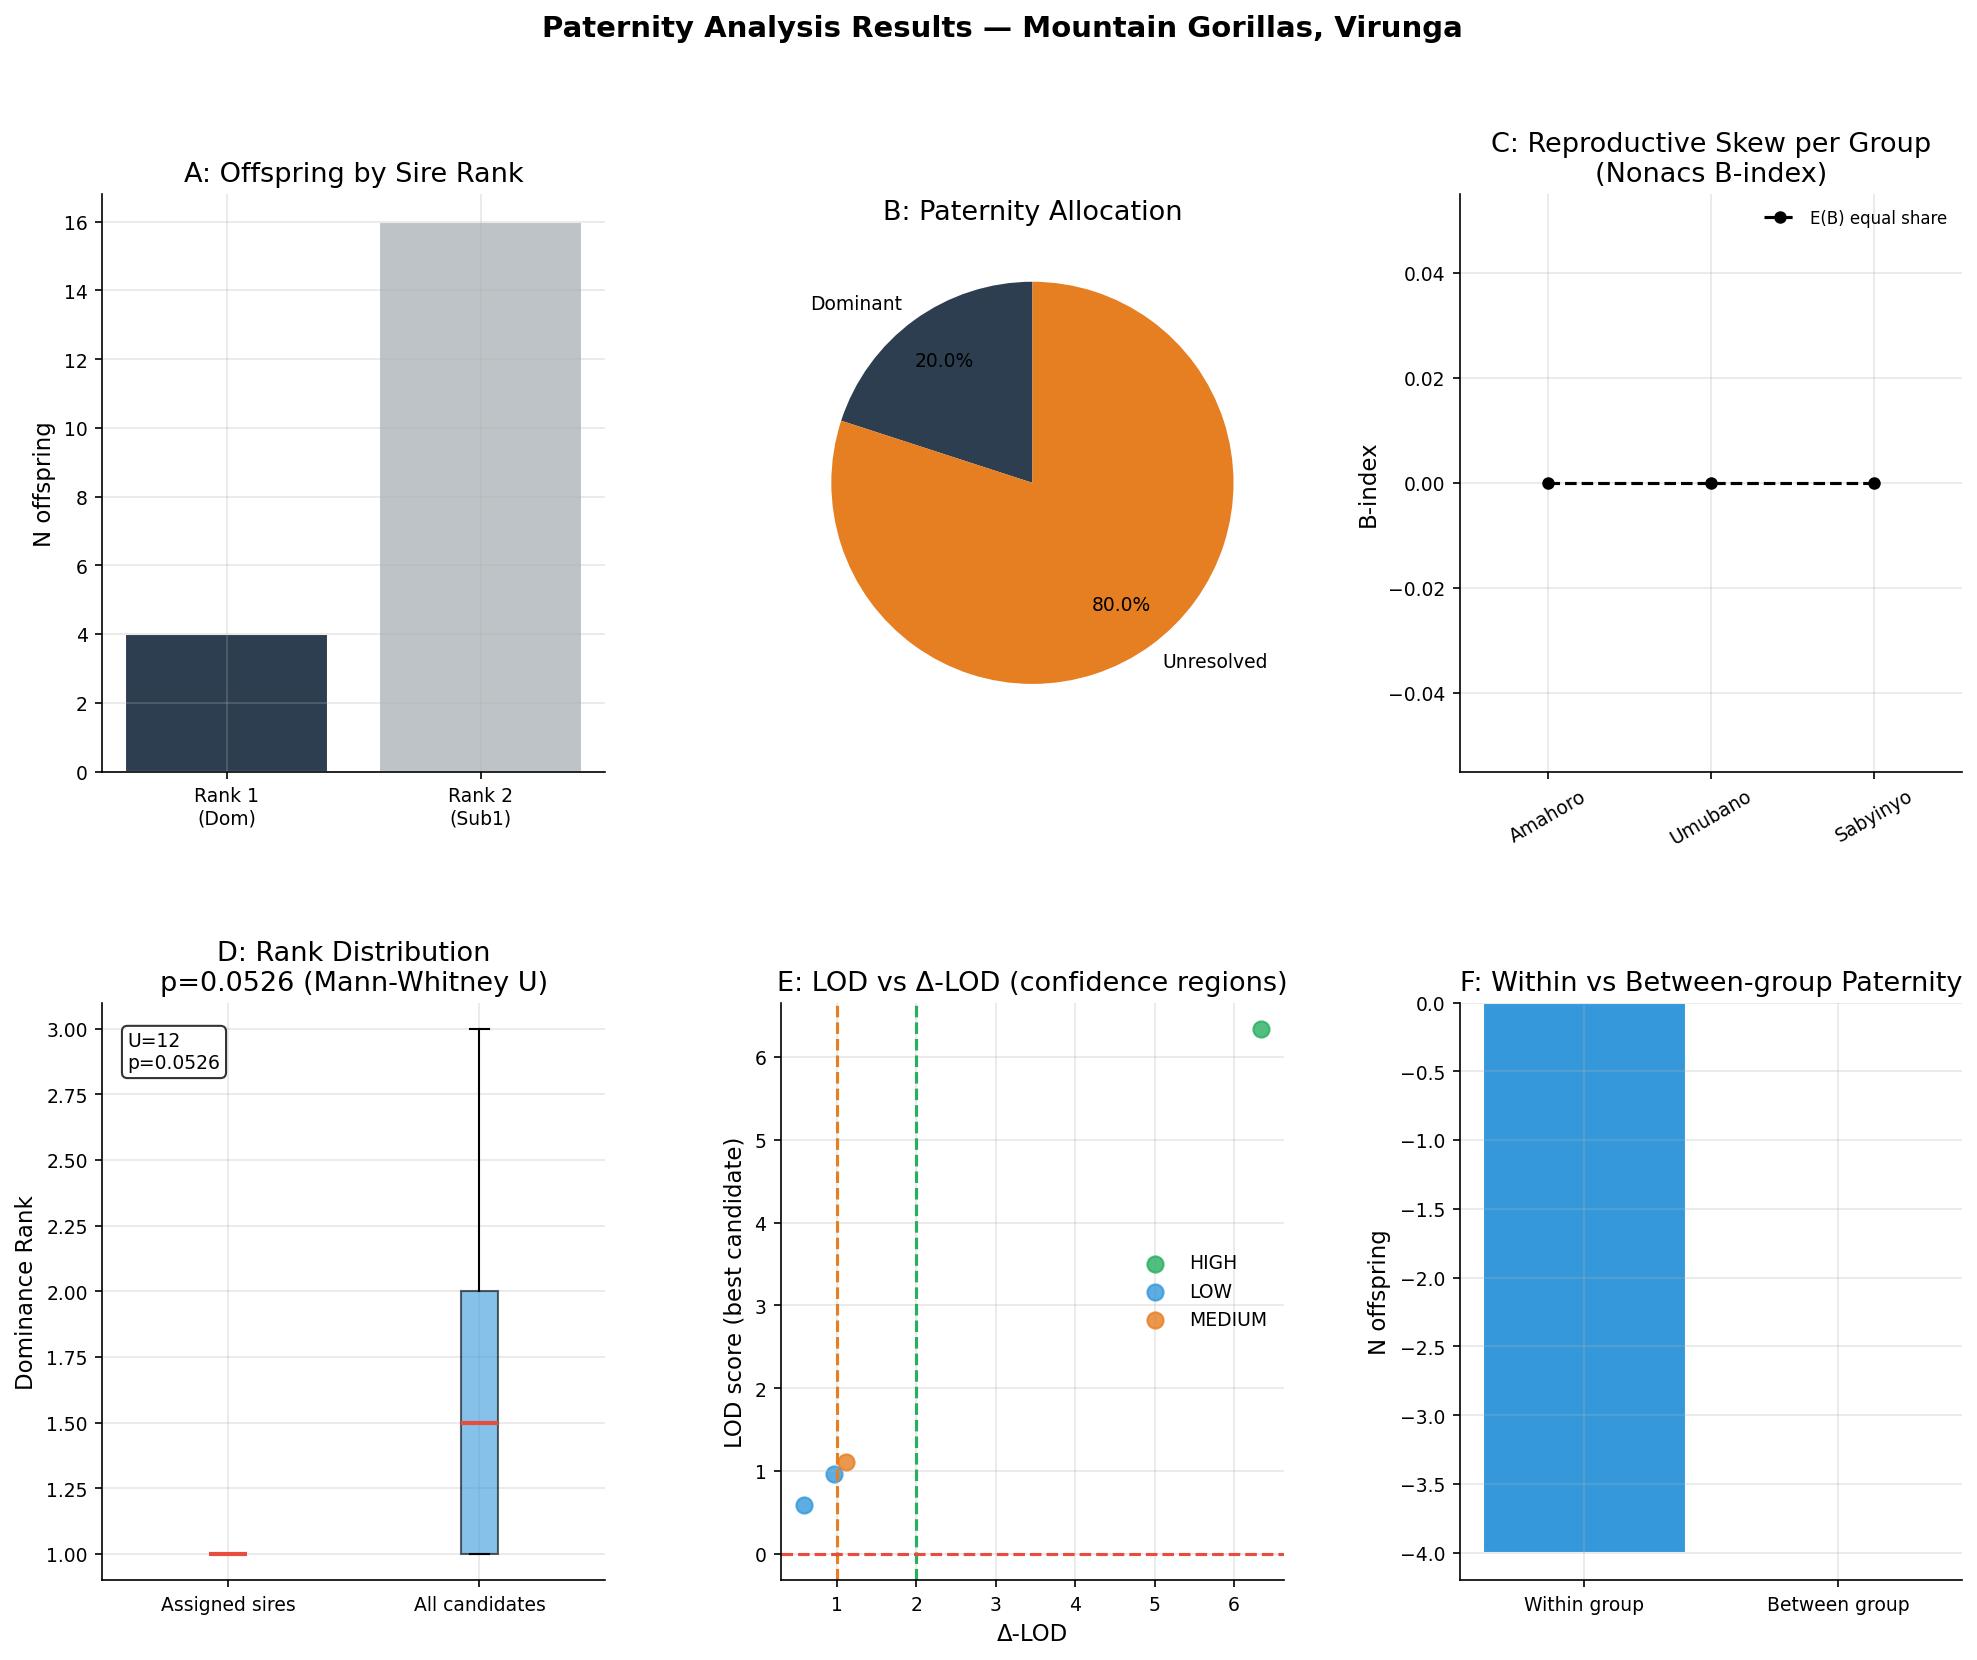

In [55]:
# Cell 11 — Paternity visualisation dashboard
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)
fig.suptitle('Paternity Analysis Results — Mountain Gorillas, Virunga', fontsize=14, fontweight='bold')

# A: Offspring by sire rank (all groups pooled)
ax = fig.add_subplot(gs[0, 0])
rank_cats = ['Rank 1\n(Dom)', 'Rank 2\n(Sub1)', 'Rank 3\n(Sub2)', 'Unresolved']
n_r1 = (assigned['sire_rank'] == 1).sum()
n_r2 = (assigned['sire_rank'] == 2).sum()
n_r3 = (assigned['sire_rank'] == 3).sum()
n_un = n_off - n_assigned
vals = [n_r1, n_r2, n_r3, n_un]
colors_r = ['#2C3E50','#E67E22','#27AE60','#BDC3C7']
ax.bar(rank_cats[:len([v for v in vals if v>0])],
       [v for v in vals if v>0],
       color=[c for c,v in zip(colors_r, vals) if v>0],
       edgecolor='white')
ax.set_ylabel('N offspring')
ax.set_title('A: Offspring by Sire Rank')

# B: Pie — paternity breakdown
ax = fig.add_subplot(gs[0, 1])
pie_vals   = [v for v in [n_r1, n_r2+n_r3, n_un] if v > 0]
pie_labels = [l for l,v in zip(['Dominant','Subordinate','Unresolved'],[n_r1,n_r2+n_r3,n_un]) if v>0]
pie_colors = ['#2C3E50','#E67E22','#BDC3C7'][:len(pie_vals)]
wedges, texts, autotexts = ax.pie(pie_vals, labels=pie_labels,
                                   colors=pie_colors, autopct='%1.1f%%',
                                   startangle=90, pctdistance=0.75)
for t in autotexts: t.set_fontsize(9)
ax.set_title('B: Paternity Allocation')

# C: B-index per group
ax = fig.add_subplot(gs[0, 2])
if not grp_skew_df.empty:
    colors_grp = sns.color_palette('Set2', len(grp_skew_df))
    bars = ax.bar(grp_skew_df['group'], grp_skew_df['B_index'], color=colors_grp, edgecolor='white')
    ax.plot(grp_skew_df['group'], grp_skew_df['E_B'], 'ko--', label='E(B) equal share', markersize=5)
    ax.set_ylabel('B-index')
    ax.set_title('C: Reproductive Skew per Group\n(Nonacs B-index)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

# D: Sire rank distribution (boxplot)
ax = fig.add_subplot(gs[1, 0])
male_df = ind_df[(ind_df['sex']=='M') & ind_df['dominance_rank'].notna()]
sire_ranks_list = assigned['sire_rank'].dropna().tolist()
all_ranks_list  = male_df['dominance_rank'].tolist()
ax.boxplot([sire_ranks_list, all_ranks_list],
           labels=['Assigned sires', 'All candidates'],
           patch_artist=True,
           boxprops=dict(facecolor='#3498DB', alpha=0.6),
           medianprops=dict(color='#E74C3C', lw=2))
ax.set_ylabel('Dominance Rank')
ax.set_title(f'D: Rank Distribution\np={mw_result["p_value"]:.4f} (Mann-Whitney U)')
ax.text(0.05, 0.95, f'U={mw_result["U_statistic"]:.0f}\np={mw_result["p_value"]:.4f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# E: LOD score vs confidence
ax = fig.add_subplot(gs[1, 1])
for conf, grp in assigned.groupby('confidence'):
    ax.scatter(grp['delta_lod'], grp['lod_score'],
               label=conf, color=conf_colors.get(conf,'grey'), s=60, alpha=0.8)
ax.axvline(1.0, color='#E67E22', ls='--', lw=1.5)
ax.axvline(2.0, color='#27AE60', ls='--', lw=1.5)
ax.axhline(0.0, color='#E74C3C', ls='--', lw=1.5)
ax.set_xlabel('Δ-LOD')
ax.set_ylabel('LOD score (best candidate)')
ax.set_title('E: LOD vs Δ-LOD (confidence regions)')
ax.legend()

# F: Within- vs between-group paternity
ax = fig.add_subplot(gs[1, 2])
within  = (~assigned['extra_group_sire'].fillna(False)).sum()
between = assigned['extra_group_sire'].fillna(False).sum()
ax.bar(['Within group', 'Between group'], [within, between],
       color=['#3498DB','#E74C3C'], edgecolor='white')
ax.set_ylabel('N offspring')
ax.set_title('F: Within vs Between-group Paternity')

plt.tight_layout()
save_figure(fig, '03_paternity_dashboard')
plt.show()

In [56]:
# Cell 12 — Save results and print key findings
key_findings = {
    'n_offspring_tested':          n_off,
    'n_assigned':                  int(n_assigned),
    'assignment_rate_pct':         round(100*n_assigned/n_off, 1),
    'pct_sired_by_dominant':       round(100*n_r1/n_assigned, 1) if n_assigned else 0,
    'pct_sired_by_subordinate':    round(100*(n_r2+n_r3)/n_assigned, 1) if n_assigned else 0,
    'pct_unresolved':              round(100*n_un/n_off, 1),
    'B_index_population':          b_result['B'],
    'B_expected_equal_sharing':    b_result['E_B'],
    'skew_ratio':                  b_result.get('skew_ratio'),
    'permutation_p':               perm_result['p_value'],
    'dominance_paternity_MW_p':    mw_result['p_value'],
    'accuracy_vs_truth':           acc.get('accuracy'),
}

print('=== KEY FINDINGS (Notebook 03) ===')
for k, v in key_findings.items():
    print(f'  {k}: {v}')

pd.Series(key_findings).to_frame('value').to_csv(TAB_DIR / 'key_findings_paternity.csv')
print('\nNotebook 03 complete. Proceed to 04_kinship_analysis.ipynb')

=== KEY FINDINGS (Notebook 03) ===
  n_offspring_tested: 20
  n_assigned: 4
  assignment_rate_pct: 20.0
  pct_sired_by_dominant: 100.0
  pct_sired_by_subordinate: 0.0
  pct_unresolved: 80.0
  B_index_population: 0.041667
  B_expected_equal_sharing: 0.222222
  skew_ratio: 0.188
  permutation_p: 0.725
  dominance_paternity_MW_p: 0.0526
  accuracy_vs_truth: 0.2857

Notebook 03 complete. Proceed to 04_kinship_analysis.ipynb
